# Direct BPS Optimization

Instead of predicting mid-prices and converting to positions, this model **directly outputs position allocations** and trains with execution cost (BPS) as the loss function via a differentiable walk-the-book simulator.

Key ideas:
- Model outputs 60 logits → softmax × volume_to_fill = positions
- Loss = BPS² via differentiable walk-the-book (PyTorch ops, supports autograd)
- No intermediate price prediction step
- Model can learn ANY allocation pattern (not restricted to last K seconds)

In [2]:
import os, sys, subprocess

# Colab setup
if not os.path.isdir("/content/Ultramarin/utils"):
    subprocess.run(["git", "clone", "-q", "-b", "potentially-improve-model",
                    "https://github.com/JosephZacharyGawlik/Ultramarin.git"],
                   cwd="/content")
os.chdir("/content/Ultramarin")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import random
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from data.simulate_walk_the_book import simulate_walk_the_book
from utils.utils import compute_ofi, ASK_PRICE_COLS, ASK_VOL_COLS, BID_PRICE_COLS, BID_VOL_COLS
from utils.datastuff import TrainCfg, LOBProcessor
from utils.train import chrono_split
from models.DeepLOB import DeepLOBEncoder
import warnings

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
warnings.filterwarnings("ignore", category=UserWarning)

device: cuda


In [3]:
# Copy data from Google Drive
dst = "/content/Ultramarin/data"
if not os.path.isfile(os.path.join(dst, "BTCUSDT/X_train.parquet")):
    from google.colab import drive
    drive.mount('/content/drive')
    src = "/content/drive/MyDrive/data"
    os.makedirs(dst, exist_ok=True)
    subprocess.run(["cp", "-r", f"{src}/.", dst], capture_output=True, text=True)
    print("Data copied.")
else:
    print("Data already present.")

Mounted at /content/drive
Data copied.


In [ ]:
# === CONFIGURATION ===
# Change this single variable to switch currencies
data_asset = "ETHUSDT"

KNOWN_VOLUMES = {
    "BTCUSDT": 4.0, "ETHUSDT": 55.0, "LTCUSDT": 51.0,
    "SOLUSDT": 315.0, "ADAUSDT": 10436.0, "DOGEUSDT": 60349.0, "XRPUSDT": 13736.0,
}
OPTIMAL_K = {
    "BTCUSDT": 14, "ETHUSDT": 26, "LTCUSDT": 16,
    "SOLUSDT": 17, "ADAUSDT": 7, "DOGEUSDT": 20, "XRPUSDT": 20,
}

volume_to_fill = KNOWN_VOLUMES[data_asset]
K_SECONDS = OPTIMAL_K[data_asset]

root = Path("data")
X_path = root / data_asset / "X_train.parquet"
Y_path = root / data_asset / "y_train.parquet"

print(f"Currency: {data_asset}")
print(f"Volume to fill: {volume_to_fill}")
print(f"TWAP K: {K_SECONDS}")

In [5]:
# Column definitions for model input
LOB_COLS = []
for i in range(1, 6):
    LOB_COLS.append(f"ask_price_{i}")
    LOB_COLS.append(f"ask_vol_{i}")
    LOB_COLS.append(f"bid_price_{i}")
    LOB_COLS.append(f"bid_vol_{i}")

OFI_COLS = ['ofi_1', 'ofi_2', 'ofi_3', 'ofi_4', 'ofi_5', 'ofi_agg']
FEATURE_COLS = LOB_COLS + ["mid_price"] + OFI_COLS
print(f"Features: {len(FEATURE_COLS)} (20 LOB + 1 mid_price + 6 OFI)")

Features: 27 (20 LOB + 1 mid_price + 6 OFI)


In [6]:
# === DATA PIPELINE ===
# Load raw data
X_raw = pd.read_parquet(X_path).sort_values(["anonymized_id", "time_in_hour"])
Y_raw = pd.read_parquet(Y_path).sort_values(["anonymized_id", "time_in_hour"])

# Chronological split
x_train_df, x_val_df, y_train_df, y_val_df = chrono_split(X_raw, Y_raw, val_ratio=0.2)

# Add mid_price
for df in [x_train_df, x_val_df, y_train_df, y_val_df]:
    df["mid_price"] = (df["ask_price_1"] + df["bid_price_1"]) / 2.0

# Compute OFI features
x_train_df = compute_ofi(x_train_df)
x_val_df = compute_ofi(x_val_df)
y_train_df = compute_ofi(y_train_df)
y_val_df = compute_ofi(y_val_df)

# Process X through LOBProcessor (normalizes)
processor = LOBProcessor(TrainCfg(), device=device)

train_out = processor.process(pl.from_pandas(x_train_df), pl.from_pandas(y_train_df))
val_out = processor.process(pl.from_pandas(x_val_df), pl.from_pandas(y_val_df))

# Reorder features to match FEATURE_COLS
feature_indices = [processor.feature_map[col] for col in FEATURE_COLS]

X_train = train_out["X"][:, :, feature_indices]  # [T, N_train, F]
X_val = val_out["X"][:, :, feature_indices]       # [T, N_val, F]

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"Train IDs: {train_out['X_id_map'].shape[0]}, Val IDs: {val_out['X_id_map'].shape[0]}")

X_train: torch.Size([3540, 564, 27])
X_val: torch.Size([3540, 141, 27])
Train IDs: 564, Val IDs: 141


In [7]:
# === CLEAN Y DATA (raw order book for walk-the-book) ===
# Use LOBProcessor's cleaning (cross-join grid, backfill, ffill, zero-fill)
# but extract RAW values before normalization.

from utils.utils import df_to_tensor

def extract_clean_book_tensors(y_df, processor, id_map_ref):
    """Clean Y data using LOBProcessor, then extract raw order book tensors.
    
    Returns tensors aligned with the normalized X tensors (same ID ordering).
    """
    y_pl = pl.from_pandas(y_df)
    y_clean = processor._apply_cleaning(y_pl)
    
    # Convert to tensor: [60, N, F]
    y_tensor, y_id_map = df_to_tensor(y_clean, seq_len=60)
    
    # Build column index map from the cleaned DataFrame
    exclude = ["anonymized_id", "time_in_hour"]
    col_names = [c for c in y_clean.columns if c not in exclude]
    col_map = {name: i for i, name in enumerate(col_names)}
    
    # Extract raw order book arrays: [60, N, 5]
    ask_p_idx = [col_map[c] for c in ASK_PRICE_COLS]
    ask_v_idx = [col_map[c] for c in ASK_VOL_COLS]
    bid_p_idx = [col_map[c] for c in BID_PRICE_COLS]
    bid_v_idx = [col_map[c] for c in BID_VOL_COLS]
    close_idx = col_map["close"]
    
    ask_prices = y_tensor[:, :, ask_p_idx]  # [60, N, 5]
    ask_vols = y_tensor[:, :, ask_v_idx]
    bid_prices = y_tensor[:, :, bid_p_idx]
    bid_vols = y_tensor[:, :, bid_v_idx]
    close_prices = y_tensor[-1, :, close_idx]  # [N] - last second's close
    
    return {
        "ask_prices": ask_prices,   # [60, N, 5]
        "ask_vols": ask_vols,
        "bid_prices": bid_prices,
        "bid_vols": bid_vols,
        "close_prices": close_prices,  # [N]
        "id_map": y_id_map,
    }

train_book = extract_clean_book_tensors(y_train_df, processor, train_out["X_id_map"])
val_book = extract_clean_book_tensors(y_val_df, processor, val_out["X_id_map"])

print(f"Train book ask_prices: {train_book['ask_prices'].shape}")
print(f"Val book ask_prices: {val_book['ask_prices'].shape}")
print(f"Train close_prices: {train_book['close_prices'].shape}")
print(f"Val close_prices: {val_book['close_prices'].shape}")

Train book ask_prices: torch.Size([60, 564, 5])
Val book ask_prices: torch.Size([60, 141, 5])
Train close_prices: torch.Size([564])
Val close_prices: torch.Size([141])


In [8]:
# === ALIGN X AND Y IDS ===
# X and Y may have different ID sets after cleaning.
# We need to keep only instruments present in BOTH.

def align_x_y(X_tensor, x_id_map, book_data):
    """Keep only instruments that appear in both X and Y.
    
    X_tensor: [T_x, N_x, F]
    book_data: dict with tensors [60, N_y, ...] and id_map
    Returns aligned X_tensor, book_data with matching instruments.
    """
    x_ids = {int(x_id_map[i, 1].item()): i for i in range(x_id_map.shape[0])}
    y_ids = {int(book_data['id_map'][i, 1].item()): i for i in range(book_data['id_map'].shape[0])}
    
    common_ids = sorted(set(x_ids.keys()) & set(y_ids.keys()))
    x_indices = [x_ids[uid] for uid in common_ids]
    y_indices = [y_ids[uid] for uid in common_ids]
    
    X_aligned = X_tensor[:, x_indices, :]
    aligned_book = {
        "ask_prices": book_data["ask_prices"][:, y_indices, :],
        "ask_vols": book_data["ask_vols"][:, y_indices, :],
        "bid_prices": book_data["bid_prices"][:, y_indices, :],
        "bid_vols": book_data["bid_vols"][:, y_indices, :],
        "close_prices": book_data["close_prices"][y_indices],
    }
    return X_aligned, aligned_book, common_ids

X_train, train_book, train_ids = align_x_y(X_train, train_out["X_id_map"], train_book)
X_val, val_book, val_ids = align_x_y(X_val, val_out["X_id_map"], val_book)

print(f"Aligned train: X={X_train.shape}, book ask_prices={train_book['ask_prices'].shape}")
print(f"Aligned val: X={X_val.shape}, book ask_prices={val_book['ask_prices'].shape}")

Aligned train: X=torch.Size([3540, 564, 27]), book ask_prices=torch.Size([60, 564, 5])
Aligned val: X=torch.Size([3540, 141, 27]), book ask_prices=torch.Size([60, 141, 5])


In [9]:
# === DATASET ===

class DirectBPSDataset(Dataset):
    """Dataset that returns normalized X input and raw order book data."""
    
    def __init__(self, X_tensor, book_data, close_prices, input_window=600):
        # X_tensor: [T, N, F]
        # book tensors: [60, N, 5]
        # close_prices: [N]
        self.X = X_tensor
        self.ask_prices = book_data["ask_prices"]    # [60, N, 5]
        self.ask_vols = book_data["ask_vols"]
        self.bid_prices = book_data["bid_prices"]
        self.bid_vols = book_data["bid_vols"]
        self.close_prices = close_prices              # [N]
        self.input_window = input_window
    
    def __len__(self):
        return self.X.shape[1]  # N instruments
    
    def __getitem__(self, idx):
        x = self.X[-self.input_window:, idx, :]       # [input_window, F]
        ask_p = self.ask_prices[:, idx, :]             # [60, 5]
        ask_v = self.ask_vols[:, idx, :]               # [60, 5]
        bid_p = self.bid_prices[:, idx, :]             # [60, 5]
        bid_v = self.bid_vols[:, idx, :]               # [60, 5]
        close = self.close_prices[idx]                 # scalar
        return x, ask_p, ask_v, bid_p, bid_v, close

INPUT_WINDOW = 600

train_dataset = DirectBPSDataset(X_train, train_book, train_book["close_prices"], INPUT_WINDOW)
val_dataset = DirectBPSDataset(X_val, val_book, val_book["close_prices"], INPUT_WINDOW)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset)} instruments")
print(f"Val: {len(val_dataset)} instruments")

# Quick shape check
x, ap, av, bp, bv, c = train_dataset[0]
print(f"Sample shapes: x={x.shape}, ask_p={ap.shape}, ask_v={av.shape}, close={c.shape}")

Train: 564 instruments
Val: 141 instruments
Sample shapes: x=torch.Size([600, 27]), ask_p=torch.Size([60, 5]), ask_v=torch.Size([60, 5]), close=torch.Size([])


In [10]:
# === DIFFERENTIABLE WALK-THE-BOOK ===

def diff_walk_the_book(positions, ask_prices, ask_vols, volume_to_fill):
    """Differentiable walk-the-book simulator (buy side only).
    
    All inputs are PyTorch tensors with gradients.
    
    Args:
        positions: [B, 60] - volume to buy at each second (from softmax * vol)
        ask_prices: [B, 60, 5] - ask prices at 5 levels
        ask_vols: [B, 60, 5] - ask volumes at 5 levels
        volume_to_fill: float - total volume target
    
    Returns:
        vwap: [B] - volume-weighted average price
        total_filled: [B] - total volume actually filled
    """
    B = positions.shape[0]
    total_cost = torch.zeros(B, device=positions.device)
    total_filled = torch.zeros(B, device=positions.device)
    carry = torch.zeros(B, device=positions.device)
    
    for t in range(60):
        remaining = positions[:, t] + carry  # [B]
        carry = torch.zeros(B, device=positions.device)
        
        for level in range(5):
            price = ask_prices[:, t, level]   # [B]
            avail = ask_vols[:, t, level]      # [B]
            
            # Replace NaN with 0 for safety
            price = torch.nan_to_num(price, nan=0.0)
            avail = torch.nan_to_num(avail, nan=0.0)
            
            # Volume we can take at this level (element-wise min)
            take = torch.minimum(remaining, avail)  # [B]
            take = torch.clamp(take, min=0.0)
            
            total_cost = total_cost + take * price
            total_filled = total_filled + take
            remaining = remaining - take
            remaining = torch.clamp(remaining, min=0.0)
        
        carry = remaining
    
    # VWAP
    vwap = total_cost / (total_filled + 1e-10)
    
    return vwap, total_filled


def bps_loss(positions, ask_prices, ask_vols, close_prices, volume_to_fill):
    """Compute BPS² loss through differentiable walk-the-book.
    
    Args:
        positions: [B, 60]
        ask_prices: [B, 60, 5]
        ask_vols: [B, 60, 5]
        close_prices: [B]
        volume_to_fill: float
    
    Returns:
        loss: scalar - mean BPS² across batch
        bps_values: [B] - BPS per instrument (detached, for logging)
    """
    vwap, total_filled = diff_walk_the_book(positions, ask_prices, ask_vols, volume_to_fill)
    
    # BPS = |VWAP - close| / close * 10000
    # Optimize (VWAP - close)² / close² * 10000² for smooth gradients
    bps_sq = ((vwap - close_prices) / (close_prices + 1e-10)) ** 2 * (10000 ** 2)
    
    # Volume penalty: penalize underfill
    fill_ratio = total_filled / (volume_to_fill + 1e-10)
    fill_penalty = torch.clamp(1.0 / (fill_ratio + 1e-10), max=100.0)
    
    loss = (bps_sq * fill_penalty).mean()
    
    # For logging: actual BPS values
    with torch.no_grad():
        bps_actual = torch.abs(vwap - close_prices) / (close_prices + 1e-10) * 10000 * fill_penalty
    
    return loss, bps_actual

print("Differentiable walk-the-book defined.")

Differentiable walk-the-book defined.


In [11]:
# === VERIFY: Differentiable WTB matches numpy WTB ===

# Grab one sample (already on GPU from df_to_tensor)
x_s, ap_s, av_s, bp_s, bv_s, c_s = train_dataset[0]

# Create TWAP positions on same device
twap_pos = torch.zeros(60, device=ap_s.device)
twap_pos[-K_SECONDS:] = volume_to_fill / K_SECONDS

# Diff WTB (batch dim = 1)
vwap_diff, filled_diff = diff_walk_the_book(
    twap_pos.unsqueeze(0),
    ap_s.unsqueeze(0),
    av_s.unsqueeze(0),
    volume_to_fill
)

# Numpy WTB (move to CPU for numpy)
filled_np, vwap_np = simulate_walk_the_book(
    twap_pos.cpu().numpy(),
    ap_s.cpu().numpy(), av_s.cpu().numpy(),
    bp_s.cpu().numpy(), bv_s.cpu().numpy()
)

print(f"Diff WTB:  VWAP={vwap_diff.item():.6f}, Filled={filled_diff.item():.4f}")
print(f"Numpy WTB: VWAP={vwap_np:.6f}, Filled={filled_np:.4f}")
print(f"VWAP diff: {abs(vwap_diff.item() - vwap_np):.10f}")
print(f"Fill diff: {abs(filled_diff.item() - filled_np):.10f}")

# Gradient check: ensure gradients flow
test_logits = torch.randn(1, 60, device=device, requires_grad=True)
test_pos = torch.softmax(test_logits, dim=1) * volume_to_fill
loss, _ = bps_loss(test_pos, ap_s.unsqueeze(0), av_s.unsqueeze(0), c_s.unsqueeze(0), volume_to_fill)
loss.backward()
print(f"\nGradient flows: {test_logits.grad is not None}")
print(f"Grad norm: {test_logits.grad.norm().item():.6f}")
print(f"Any NaN grads: {test_logits.grad.isnan().any().item()}")

Diff WTB:  VWAP=110176.695312, Filled=3.7123
Numpy WTB: VWAP=110176.695312, Filled=3.7123
VWAP diff: 0.0000000000
Fill diff: 0.0000000000

Gradient flows: True
Grad norm: 0.104343
Any NaN grads: False


In [12]:
# === MODEL: DeepLOB Encoder + Cross-Attention Decoder + Position Head ===
# Uses 60 learned query vectors that each cross-attend to the encoder output,
# producing [B, 60, d] which is projected to position logits.
# This avoids the single-context-vector bottleneck.

class DirectBPSModel(nn.Module):
    def __init__(self, hidden=128, dropout=0.1, num_extra_features=0):
        super().__init__()
        self.num_extra_features = num_extra_features
        enc_dim = 2 * hidden  # bidirectional
        
        # 1. Encoder (same as SuperModel)
        self.spatial = DeepLOBEncoder(in_ch=1, dropout=dropout)
        encoder_input_size = 192 + num_extra_features
        self.encoder = nn.LSTM(
            input_size=encoder_input_size,
            hidden_size=hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
            dropout=0.0,
        )
        self.enc_dropout = nn.Dropout(dropout)
        
        # 2. Cross-attention decoder: 60 learned queries attend to encoder
        self.queries = nn.Parameter(torch.randn(60, enc_dim) * 0.02)  # [60, 2H]
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=enc_dim,
            num_heads=4,
            dropout=dropout,
            batch_first=True,
        )
        self.norm = nn.LayerNorm(enc_dim)
        
        # 3. Position head: per-timestep feature → 1 logit
        self.head = nn.Sequential(
            nn.Linear(enc_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    
    def forward(self, x):
        """
        x: [B, T, F] where F = 20 LOB + extra features
        Returns: [B, 60] softmax position weights (sum to 1)
        """
        B = x.shape[0]
        
        # Split LOB features (for CNN) and extra features
        lob_features = x[:, :, :20]
        h_spatial = self.spatial(lob_features)  # [B, T', 192]
        
        if self.num_extra_features > 0:
            T_prime = h_spatial.shape[1]
            extra = x[:, -T_prime:, 20:]  # [B, T', N_extra]
            h_spatial = torch.cat([h_spatial, extra], dim=-1)
        
        # Encode
        enc_out, _ = self.encoder(h_spatial)  # [B, T', 2H]
        enc_out = self.enc_dropout(enc_out)
        
        # Cross-attention: 60 queries attend to encoder
        q = self.queries.unsqueeze(0).expand(B, -1, -1)  # [B, 60, 2H]
        decoded, _ = self.cross_attn(q, enc_out, enc_out)  # [B, 60, 2H]
        decoded = self.norm(decoded + q)  # residual + norm
        
        # Position logits → softmax
        logits = self.head(decoded).squeeze(-1)  # [B, 60]
        return torch.softmax(logits, dim=1)  # [B, 60] sums to 1

# Test model
num_extra = len(FEATURE_COLS) - 20
model = DirectBPSModel(hidden=128, dropout=0.1, num_extra_features=num_extra).to(device)
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

# Quick forward pass
x_test = torch.randn(2, INPUT_WINDOW, len(FEATURE_COLS)).to(device)
out = model(x_test)
print(f"Output shape: {out.shape}, sum per sample: {out.sum(dim=1)}")

Model params: 721,505
Output shape: torch.Size([2, 60]), sum per sample: tensor([1., 1.], device='cuda:0', grad_fn=<SumBackward1>)


In [13]:
# === TRAINING LOOP ===
import copy
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS = 100
LR = 5e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 15
MIN_LR = 1e-6

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=MIN_LR)

best_val_bps = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_bps_all = []
    train_loss_sum = 0.0
    train_count = 0
    
    for x_batch, ap_batch, av_batch, bp_batch, bv_batch, close_batch in train_loader:
        x_batch = x_batch.to(device)
        ap_batch = ap_batch.to(device)
        av_batch = av_batch.to(device)
        close_batch = close_batch.to(device)
        
        optimizer.zero_grad()
        
        # Forward: model outputs allocation weights [B, 60]
        weights = model(x_batch)  # [B, 60], sums to 1
        positions = weights * volume_to_fill  # [B, 60], sums to volume_to_fill
        
        # Loss via differentiable walk-the-book
        loss, bps_vals = bps_loss(positions, ap_batch, av_batch, close_batch, volume_to_fill)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss_sum += loss.item() * x_batch.size(0)
        train_bps_all.append(bps_vals.detach().cpu())
        train_count += x_batch.size(0)
    
    train_loss = train_loss_sum / max(train_count, 1)
    train_bps = torch.cat(train_bps_all).mean().item()
    
    # --- Val ---
    model.eval()
    val_bps_all = []
    val_loss_sum = 0.0
    val_count = 0
    
    with torch.no_grad():
        for x_batch, ap_batch, av_batch, bp_batch, bv_batch, close_batch in val_loader:
            x_batch = x_batch.to(device)
            ap_batch = ap_batch.to(device)
            av_batch = av_batch.to(device)
            close_batch = close_batch.to(device)
            
            weights = model(x_batch)
            positions = weights * volume_to_fill
            
            loss, bps_vals = bps_loss(positions, ap_batch, av_batch, close_batch, volume_to_fill)
            
            val_loss_sum += loss.item() * x_batch.size(0)
            val_bps_all.append(bps_vals.cpu())
            val_count += x_batch.size(0)
    
    val_loss = val_loss_sum / max(val_count, 1)
    val_bps = torch.cat(val_bps_all).mean().item()
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    
    print(f"Epoch {epoch+1:02d} | Train BPS: {train_bps:.4f} | Val BPS: {val_bps:.4f} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.2e}")
    
    # Early stopping on val BPS
    if val_bps < best_val_bps:
        best_val_bps = val_bps
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model (val BPS: {best_val_bps:.4f})")

Epoch 01 | Train BPS: 1.3053 | Val BPS: 1.2929 | Train Loss: 2.8589 | Val Loss: 2.8102 | LR: 5.00e-04
Epoch 02 | Train BPS: 1.1690 | Val BPS: 1.3613 | Train Loss: 1.9388 | Val Loss: 3.3183 | LR: 5.00e-04
Epoch 03 | Train BPS: 1.1449 | Val BPS: 1.2659 | Train Loss: 1.8338 | Val Loss: 2.5492 | LR: 4.99e-04
Epoch 04 | Train BPS: 1.1447 | Val BPS: 1.2613 | Train Loss: 1.8886 | Val Loss: 2.4982 | LR: 4.98e-04
Epoch 05 | Train BPS: 1.1735 | Val BPS: 1.3575 | Train Loss: 1.9075 | Val Loss: 3.2183 | LR: 4.97e-04
Epoch 06 | Train BPS: 1.1607 | Val BPS: 1.3211 | Train Loss: 1.9177 | Val Loss: 2.8863 | LR: 4.96e-04
Epoch 07 | Train BPS: 1.1505 | Val BPS: 1.2699 | Train Loss: 1.9151 | Val Loss: 2.6425 | LR: 4.94e-04
Epoch 08 | Train BPS: 1.1378 | Val BPS: 1.2437 | Train Loss: 1.8341 | Val Loss: 2.3788 | LR: 4.92e-04
Epoch 09 | Train BPS: 1.1458 | Val BPS: 1.2955 | Train Loss: 1.8172 | Val Loss: 2.7127 | LR: 4.90e-04
Epoch 10 | Train BPS: 1.1321 | Val BPS: 1.2637 | Train Loss: 1.7748 | Val Loss: 2.

# Evaluation: Compare Direct BPS model vs TWAP vs True Oracle

In [14]:
# === EVALUATION: Compare model vs TWAP vs True Oracle using NUMPY walk-the-book ===
from scipy.optimize import minimize

def walk_the_book_cost(volume, ask_prices_row, ask_vols_row):
    """Compute total cost of buying `volume` units at one second."""
    remaining = volume
    total_cost = 0.0
    filled = 0.0
    for level in range(len(ask_prices_row)):
        price = ask_prices_row[level]
        avail = ask_vols_row[level]
        if np.isnan(price) or np.isnan(avail):
            continue
        take = min(remaining, avail)
        total_cost += take * price
        filled += take
        remaining -= take
        if remaining <= 1e-12:
            break
    return total_cost, filled

def true_oracle_objective(v_alloc, ask_prices, ask_vols, close_price, vol_to_fill):
    total_cost = 0.0
    total_filled = 0.0
    for t in range(len(v_alloc)):
        if v_alloc[t] < 1e-12:
            continue
        cost, filled = walk_the_book_cost(v_alloc[t], ask_prices[t], ask_vols[t])
        total_cost += cost
        total_filled += filled
    if total_filled < 1e-12:
        return 1e12
    vwap = total_cost / total_filled
    fill_penalty = (vol_to_fill - total_filled) ** 2 * 1e6
    return (vwap - close_price) ** 2 + fill_penalty

model.eval()

model_bps_list = []
twap_bps_list = []
oracle_bps_list = []
model_positions_all = []

with torch.no_grad():
    for x_batch, ap_batch, av_batch, bp_batch, bv_batch, close_batch in val_loader:
        x_batch = x_batch.to(device)
        
        weights = model(x_batch)
        positions = (weights * volume_to_fill).cpu().numpy()
        
        ap_np = ap_batch.cpu().numpy()
        av_np = av_batch.cpu().numpy()
        bp_np = bp_batch.cpu().numpy()
        bv_np = bv_batch.cpu().numpy()
        close_np = close_batch.cpu().numpy()
        
        for i in range(positions.shape[0]):
            # --- Model BPS ---
            vol, avg_price = simulate_walk_the_book(
                positions[i], ap_np[i], av_np[i], bp_np[i], bv_np[i]
            )
            if vol > 0 and not np.isnan(avg_price):
                ie = np.abs(avg_price - close_np[i]) / close_np[i] * 10000
                vp = min(100.0, volume_to_fill / vol)
                model_bps_list.append(ie * vp)
            
            # --- TWAP BPS ---
            twap_pos = np.zeros(60)
            twap_pos[-K_SECONDS:] = volume_to_fill / K_SECONDS
            vol_t, avg_price_t = simulate_walk_the_book(
                twap_pos, ap_np[i], av_np[i], bp_np[i], bv_np[i]
            )
            if vol_t > 0 and not np.isnan(avg_price_t):
                ie_t = np.abs(avg_price_t - close_np[i]) / close_np[i] * 10000
                vp_t = min(100.0, volume_to_fill / vol_t)
                twap_bps_list.append(ie_t * vp_t)
            
            # --- True Oracle BPS (windowed, last K seconds) ---
            v0 = np.full(K_SECONDS, volume_to_fill / K_SECONDS)
            ap_window = ap_np[i, -K_SECONDS:]
            av_window = av_np[i, -K_SECONDS:]
            
            result = minimize(
                true_oracle_objective, v0,
                args=(ap_window, av_window, close_np[i], volume_to_fill),
                method='SLSQP',
                bounds=[(0, volume_to_fill)] * K_SECONDS,
                constraints={'type': 'eq', 'fun': lambda v: v.sum() - volume_to_fill},
                options={'maxiter': 500, 'ftol': 1e-15}
            )
            opt_alloc = np.zeros(60)
            opt_alloc[-K_SECONDS:] = result.x
            vol_o, avg_price_o = simulate_walk_the_book(
                opt_alloc, ap_np[i], av_np[i], bp_np[i], bv_np[i]
            )
            if vol_o > 0 and not np.isnan(avg_price_o):
                ie_o = np.abs(avg_price_o - close_np[i]) / close_np[i] * 10000
                vp_o = min(100.0, volume_to_fill / vol_o)
                oracle_bps_list.append(ie_o * vp_o)
            
            model_positions_all.append(positions[i])

model_bps = np.array(model_bps_list)
twap_bps = np.array(twap_bps_list)
oracle_bps = np.array(oracle_bps_list)

print(f"{'='*60}")
print(f"DIRECT BPS MODEL vs TWAP-{K_SECONDS}s vs TRUE ORACLE ({data_asset})")
print(f"{'='*60}")
print(f"Instruments evaluated: {len(model_bps)}")
print(f"")
print(f"True Oracle ({K_SECONDS}s, scipy optimal):")
print(f"  Mean:   {oracle_bps.mean():.4f} bps")
print(f"  Median: {np.median(oracle_bps):.4f} bps")
print(f"")
print(f"Direct BPS Model:")
print(f"  Mean:   {model_bps.mean():.4f} bps")
print(f"  Median: {np.median(model_bps):.4f} bps")
print(f"")
print(f"TWAP-{K_SECONDS}s:")
print(f"  Mean:   {twap_bps.mean():.4f} bps")
print(f"  Median: {np.median(twap_bps):.4f} bps")
print(f"")
print(f"Model beats TWAP by:   {twap_bps.mean() - model_bps.mean():+.4f} bps")
print(f"Oracle beats TWAP by:  {twap_bps.mean() - oracle_bps.mean():+.4f} bps")
print(f"Model vs Oracle gap:   {model_bps.mean() - oracle_bps.mean():+.4f} bps")
print(f"{'='*60}")

DIRECT BPS MODEL vs TWAP-14s vs TRUE ORACLE (BTCUSDT)
Instruments evaluated: 141

True Oracle (14s, scipy optimal):
  Mean:   0.7055 bps
  Median: 0.4578 bps

Direct BPS Model:
  Mean:   1.2007 bps
  Median: 1.0726 bps

TWAP-14s:
  Mean:   1.3232 bps
  Median: 1.1836 bps

Model beats TWAP by:   +0.1225 bps
Oracle beats TWAP by:  +0.6177 bps
Model vs Oracle gap:   +0.4952 bps


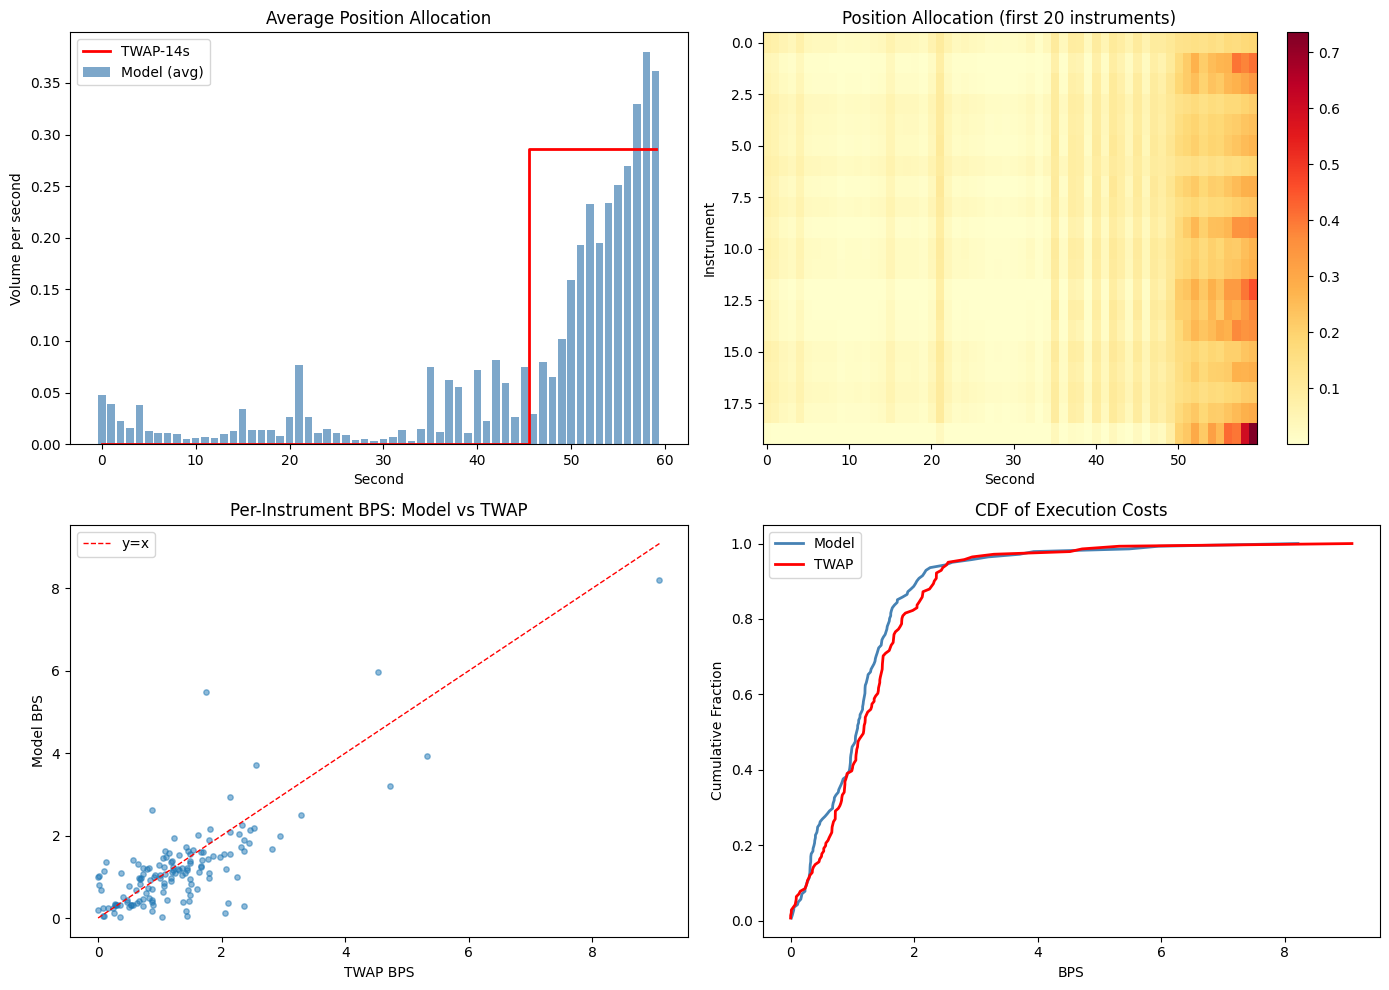

Saved figure to direct_bps_BTCUSDT.png


In [15]:
# === VISUALIZE: What did the model learn? ===
import matplotlib.pyplot as plt

# Average allocation pattern across all val instruments
model_positions_arr = np.array(model_positions_all)  # [N_val, 60]
avg_allocation = model_positions_arr.mean(axis=0)

# TWAP pattern for comparison
twap_pattern = np.zeros(60)
twap_pattern[-K_SECONDS:] = volume_to_fill / K_SECONDS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Average allocation pattern
ax = axes[0, 0]
ax.bar(range(60), avg_allocation, alpha=0.7, label='Model (avg)', color='steelblue')
ax.step(range(60), twap_pattern, where='mid', color='red', linewidth=2, label=f'TWAP-{K_SECONDS}s')
ax.set_xlabel('Second')
ax.set_ylabel('Volume per second')
ax.set_title('Average Position Allocation')
ax.legend()

# 2. Allocation heatmap (first 20 instruments)
ax = axes[0, 1]
n_show = min(20, model_positions_arr.shape[0])
im = ax.imshow(model_positions_arr[:n_show], aspect='auto', cmap='YlOrRd')
ax.set_xlabel('Second')
ax.set_ylabel('Instrument')
ax.set_title(f'Position Allocation (first {n_show} instruments)')
plt.colorbar(im, ax=ax)

# 3. Per-instrument BPS comparison
ax = axes[1, 0]
n_compare = min(len(model_bps), len(twap_bps))
ax.scatter(twap_bps[:n_compare], model_bps[:n_compare], alpha=0.5, s=15)
max_bps = max(twap_bps[:n_compare].max(), model_bps[:n_compare].max())
ax.plot([0, max_bps], [0, max_bps], 'r--', linewidth=1, label='y=x')
ax.set_xlabel('TWAP BPS')
ax.set_ylabel('Model BPS')
ax.set_title('Per-Instrument BPS: Model vs TWAP')
ax.legend()

# 4. Cumulative distribution
ax = axes[1, 1]
for bps_arr, label, color in [(model_bps, 'Model', 'steelblue'), (twap_bps, 'TWAP', 'red')]:
    sorted_bps = np.sort(bps_arr)
    cdf = np.arange(1, len(sorted_bps) + 1) / len(sorted_bps)
    ax.plot(sorted_bps, cdf, label=label, color=color, linewidth=2)
ax.set_xlabel('BPS')
ax.set_ylabel('Cumulative Fraction')
ax.set_title('CDF of Execution Costs')
ax.legend()

plt.tight_layout()
plt.savefig(f'direct_bps_{data_asset}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved figure to direct_bps_{data_asset}.png")